# Analisis Data Penjualan (Cleaning & EDA)

Notebook ini menyajikan proses **data cleaning**, **rekayasa fitur**, dan **Exploratory Data Analysis (EDA)** secara end-to-end menggunakan dataset yang diberikan pada file **`Sale+Dataset.xlsx`**.

## Tujuan
- Kinerja penjualan dan profit (Revenue, Cost, Profit, Profit Margin)
- Perbedaan performa berdasarkan **Region**, **Kategori/Segmen Produk**, serta **Channel/Device**
- **Tren** dari waktu ke waktu (bulanan/kuartalan/tahunan)
- **Outlier** dan indikasi akar masalah (root-cause candidates)
- Rekomendasi tindakan berbasis data

> Catatan: Dataset berbentuk **star schema** (fakta transaksi + tabel dimensi). Notebook ini akan melakukan *join* untuk membentuk tabel transaksi yang “enriched”.


In [5]:
# Setup & library
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

# Pengaturan tampilan
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# Lokasi file
DATA_PATH = Path("Sale+Dataset.xlsx")  # ubah bila perlu

# Opsi performa
# - Jika eksekusi terasa lambat, gunakan SAMPLE_N untuk mengambil sampel baris dari tabel fakta.
# - Set None untuk memakai seluruh data.
SAMPLE_N = None  # contoh: 200_000

# Cache untuk mempercepat re-run (dibuat setelah data berhasil di-enrich)
CACHE_PATH = Path("sales_enriched.pkl")

def _assert_file_exists(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"File tidak ditemukan: {path}. Pastikan path benar.")

_assert_file_exists(DATA_PATH)

print("Siap. File dataset:", DATA_PATH)


Siap. File dataset: Sale+Dataset.xlsx


## 1) Memuat data dari Excel

File `Sale+Dataset.xlsx` berisi beberapa sheet:
- **Sales_2015-2019**: tabel fakta transaksi (ProductID, Date, CustomerID, CampaignID, Units)
- **Product**: dimensi produk (Category, Segment, Unit Cost, Unit Price, dsb.)
- **Customer**: dimensi pelanggan (ZipCode, Email/Name)
- **Geo**: dimensi geografi (Zip → Region, State, Country, dsb.)
- **Campaign**: dimensi campaign (TrafficChannel, Device)
- **Date**: dimensi kalender (Year, Quarter, Month)

Pada tahap ini kita akan:
1. Memuat tabel-tabel dimensi
2. Memuat tabel fakta (opsional: sampling)
3. Melakukan *join* untuk menghasilkan dataset transaksi yang siap dianalisis


In [6]:
# Memuat workbook sekali untuk mengurangi overhead
xf = pd.ExcelFile(DATA_PATH, engine="openpyxl")
print("Sheet tersedia:", xf.sheet_names)

# Dimensi (relatif kecil)
df_product  = xf.parse("Product")
df_campaign = xf.parse("Campaign")
df_date     = xf.parse("Date")
df_geo      = xf.parse("Geo")

# Customer cukup besar. Ambil kolom yang dibutuhkan saja.
# Jika ini masih lambat di mesin Anda, lihat sel "Optimasi Performa" di bawah.
df_customer = xf.parse("Customer", usecols=["CustomerID", "ZipCode"])

# Fakta (transaksi)
df_fact = xf.parse("Sales_2015-2019")
if SAMPLE_N is not None:
    df_fact = df_fact.sample(SAMPLE_N, random_state=42)

print("Ukuran data:")
print(" - Fact      :", df_fact.shape)
print(" - Product   :", df_product.shape)
print(" - Customer  :", df_customer.shape)
print(" - Geo       :", df_geo.shape)
print(" - Campaign  :", df_campaign.shape)
print(" - Date      :", df_date.shape)

display(df_fact.head())


Sheet tersedia: ['Date', 'Campaign', 'Customer', 'Product', 'Geo', 'Sales_2015-2019']
Ukuran data:
 - Fact      : (611170, 5)
 - Product   : (212, 8)
 - Customer  : (282597, 2)
 - Geo       : (39948, 6)
 - Campaign  : (23, 3)
 - Date      : (2191, 6)


,ProductID,Date,CustomerID,CampaignID,Units
0,407,2019-12-31,251334,9,5
1,407,2019-12-31,202093,9,7
2,407,2019-12-31,154671,9,5
3,407,2019-12-31,82665,9,9
4,407,2019-12-31,96975,9,1


### Optimasi Performa (opsional)

Jika membaca sheet `Customer` atau `Sales_2015-2019` terasa lambat (karena ukuran file Excel besar), Anda dapat:
- Mengatur `SAMPLE_N` (misalnya 200.000) untuk eksplorasi cepat
- Menjalankan proses sekali lalu menyimpan hasil join ke file cache (`sales_enriched.pkl`)
- Mengonversi Excel ke format yang lebih cepat (CSV/Parquet) untuk pipeline produksi


## 2) Membentuk dataset transaksi (*enrichment*) + Rekayasa fitur dasar

Kita akan melakukan join berikut:
- Fact → Product (ProductID)
- Fact → Campaign (CampaignID)
- Fact → Customer (CustomerID) → Geo (ZipCode/Zip)
- Fact → Date (Date)

Lalu menghitung metrik inti:
- **Revenue** = Units × Unit Price  
- **Cost** = Units × Unit Cost  
- **Profit** = Revenue − Cost  
- **ProfitMargin** = Profit / Revenue


In [7]:
def optimize_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    """Optimasi tipe data sederhana untuk efisiensi memori."""
    out = df.copy()
    for c in out.columns:
        if out[c].dtype == "int64":
            out[c] = pd.to_numeric(out[c], downcast="integer")
        elif out[c].dtype == "float64":
            out[c] = pd.to_numeric(out[c], downcast="float")
        elif out[c].dtype == "object":
            # Coba jadikan kategori untuk kolom dengan kardinalitas rendah
            nunique = out[c].nunique(dropna=True)
            if 0 < nunique < 200:
                out[c] = out[c].astype("category")
    return out

def build_enriched_sales(df_fact, df_product, df_customer, df_geo, df_campaign, df_date):
    # Pastikan kolom tanggal bertipe datetime
    df_fact = df_fact.copy()
    df_fact["Date"] = pd.to_datetime(df_fact["Date"], errors="coerce")

    # Join dimensi
    sales = df_fact.merge(df_product, on="ProductID", how="left")
    sales = sales.merge(df_campaign, on="CampaignID", how="left")
    sales = sales.merge(df_customer, on="CustomerID", how="left")
    sales = sales.merge(df_geo, left_on="ZipCode", right_on="Zip", how="left")
    sales = sales.merge(df_date, on="Date", how="left", suffixes=("", "_dim"))

    # Rekayasa fitur finansial
    sales["Revenue"] = sales["Units"] * sales["Unit Price"]
    sales["Cost"] = sales["Units"] * sales["Unit Cost"]
    sales["Profit"] = sales["Revenue"] - sales["Cost"]
    sales["ProfitMargin"] = np.where(sales["Revenue"] != 0, sales["Profit"] / sales["Revenue"], np.nan)

    # Fitur waktu tambahan
    sales["Year"] = sales["Year"].astype("Int64")
    # Untuk analisis bulanan
    sales["YearMonth"] = sales["Date"].dt.to_period("M").astype(str)

    return optimize_dtypes(sales)

# Gunakan cache bila tersedia
if CACHE_PATH.exists():
    print("Membaca dari cache:", CACHE_PATH)
    sales = pd.read_pickle(CACHE_PATH)
else:
    print("Membangun dataset transaksi (enrichment)...")
    sales = build_enriched_sales(df_fact, df_product, df_customer, df_geo, df_campaign, df_date)
    sales.to_pickle(CACHE_PATH)
    print("Cache tersimpan:", CACHE_PATH)

print("Dataset transaksi (enriched):", sales.shape)
display(sales.head())


Membangun dataset transaksi (enrichment)...
Cache tersimpan: sales_enriched.pkl
Dataset transaksi (enriched): (611170, 31)


,ProductID,Date,CustomerID,CampaignID,Units,Product,Category,Segment,ManufacturerID,Manufacturer,Unit Cost,Unit Price,TrafficChannel,Device,ZipCode,Zip,City,State,Region,District,Country,MonthNo,MonthName,Month,Quarter,Year,Revenue,Cost,Profit,ProfitMargin,YearMonth
0,407,2019-12-31,251334,9,5,Maximus UM-12,Accessory,Accessory,7,MainOne,59,70,Banner,Tablet,1032,1032,"Goshen, MA, USA",Massachusetts,East,District #02,USA,12,Dec,Dec-15,Q4,2019,350,295,55,0.157143,2019-12
1,407,2019-12-31,202093,9,7,Maximus UM-12,Accessory,Accessory,7,MainOne,59,70,Banner,Tablet,17003,17003,"Annville, PA, USA",Pennsylvania,East,District #05,USA,12,Dec,Dec-15,Q4,2019,490,413,77,0.157143,2019-12
2,407,2019-12-31,154671,9,5,Maximus UM-12,Accessory,Accessory,7,MainOne,59,70,Banner,Tablet,28792,28792,"Hendersonville, NC, USA",North Carolina,East,District #11,USA,12,Dec,Dec-15,Q4,2019,350,295,55,0.157143,2019-12
3,407,2019-12-31,82665,9,9,Maximus UM-12,Accessory,Accessory,7,MainOne,59,70,Banner,Tablet,75501,75501,"Texarkana, TX, USA",Texas,Central,District #25,USA,12,Dec,Dec-15,Q4,2019,630,531,99,0.157143,2019-12
4,407,2019-12-31,96975,9,1,Maximus UM-12,Accessory,Accessory,7,MainOne,59,70,Banner,Tablet,97304,97304,"Salem, OR, USA",Oregon,West,District #34,USA,12,Dec,Dec-15,Q4,2019,70,59,11,0.157143,2019-12


## 3) Data Quality Check & Cleaning

Pada tahap ini kita akan memeriksa:
- Nilai kosong (missing values) terutama pada kolom kunci (harga, cost, region)
- Duplikasi baris
- Nilai tidak wajar (misal Units ≤ 0, Unit Price/Cost ≤ 0)
- Dampak pembersihan data terhadap jumlah baris

Hasil cleaning akan disimpan sebagai `sales_clean`.


In [8]:
def missing_report(df: pd.DataFrame, top_n=20):
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0].head(top_n)
    return (miss * 100).to_frame("missing_%")

print("Ringkasan missing values (Top 20):")
display(missing_report(sales, top_n=20))

# Duplikasi baris (persis sama semua kolom)
dup_count = sales.duplicated().sum()
print(f"Jumlah baris duplikat (identik): {dup_count:,} / {len(sales):,}")

# Pemeriksaan nilai tidak wajar
checks = {
    "Units <= 0": (sales["Units"] <= 0).sum(),
    "Unit Price <= 0": (sales["Unit Price"] <= 0).sum(),
    "Unit Cost <= 0": (sales["Unit Cost"] <= 0).sum(),
    "Revenue < 0": (sales["Revenue"] < 0).sum(),
}
print("Pemeriksaan nilai tidak wajar:")
for k,v in checks.items():
    print(f" - {k}: {v:,}")

# Cleaning rules (konservatif):
# 1) Hapus duplikat identik
# 2) Hapus Units <= 0
# 3) Hapus baris yang tidak punya Unit Price atau Unit Cost (tidak bisa hitung profit)
sales_clean = sales.copy()
sales_clean = sales_clean.drop_duplicates()
sales_clean = sales_clean[sales_clean["Units"] > 0]
sales_clean = sales_clean.dropna(subset=["Unit Price", "Unit Cost"])

# Jika Region kosong, kita isi sebagai "Unknown" agar tetap terhitung (opsional)
if "Region" in sales_clean.columns:
    sales_clean["Region"] = sales_clean["Region"].cat.add_categories(["Unknown"]) if str(sales_clean["Region"].dtype)=="category" else sales_clean["Region"]
    sales_clean["Region"] = sales_clean["Region"].fillna("Unknown")

print("Ukuran sebelum cleaning:", sales.shape)
print("Ukuran sesudah cleaning:", sales_clean.shape)

display(sales_clean.head())


Ringkasan missing values (Top 20):


,missing_%


Jumlah baris duplikat (identik): 19 / 611,170
Pemeriksaan nilai tidak wajar:
 - Units <= 0: 0
 - Unit Price <= 0: 0
 - Unit Cost <= 0: 0
 - Revenue < 0: 0
Ukuran sebelum cleaning: (611170, 31)
Ukuran sesudah cleaning: (611151, 31)


,ProductID,Date,CustomerID,CampaignID,Units,Product,Category,Segment,ManufacturerID,Manufacturer,Unit Cost,Unit Price,TrafficChannel,Device,ZipCode,Zip,City,State,Region,District,Country,MonthNo,MonthName,Month,Quarter,Year,Revenue,Cost,Profit,ProfitMargin,YearMonth
0,407,2019-12-31,251334,9,5,Maximus UM-12,Accessory,Accessory,7,MainOne,59,70,Banner,Tablet,1032,1032,"Goshen, MA, USA",Massachusetts,East,District #02,USA,12,Dec,Dec-15,Q4,2019,350,295,55,0.157143,2019-12
1,407,2019-12-31,202093,9,7,Maximus UM-12,Accessory,Accessory,7,MainOne,59,70,Banner,Tablet,17003,17003,"Annville, PA, USA",Pennsylvania,East,District #05,USA,12,Dec,Dec-15,Q4,2019,490,413,77,0.157143,2019-12
2,407,2019-12-31,154671,9,5,Maximus UM-12,Accessory,Accessory,7,MainOne,59,70,Banner,Tablet,28792,28792,"Hendersonville, NC, USA",North Carolina,East,District #11,USA,12,Dec,Dec-15,Q4,2019,350,295,55,0.157143,2019-12
3,407,2019-12-31,82665,9,9,Maximus UM-12,Accessory,Accessory,7,MainOne,59,70,Banner,Tablet,75501,75501,"Texarkana, TX, USA",Texas,Central,District #25,USA,12,Dec,Dec-15,Q4,2019,630,531,99,0.157143,2019-12
4,407,2019-12-31,96975,9,1,Maximus UM-12,Accessory,Accessory,7,MainOne,59,70,Banner,Tablet,97304,97304,"Salem, OR, USA",Oregon,West,District #34,USA,12,Dec,Dec-15,Q4,2019,70,59,11,0.157143,2019-12


## 4) Ringkasan KPI Utama

Kita hitung KPI tingkat agregat:
- Total Units
- Total Revenue, Cost, Profit
- Profit Margin agregat
- Jumlah transaksi (baris), unique customer, unique product
- Rentang tanggal data


In [9]:
def kpi_summary(df: pd.DataFrame) -> pd.DataFrame:
    out = {}
    out["Jumlah transaksi (baris)"] = len(df)
    out["Unique Customer"] = df["CustomerID"].nunique(dropna=True)
    out["Unique Product"] = df["ProductID"].nunique(dropna=True)
    out["Total Units"] = df["Units"].sum()
    out["Total Revenue"] = df["Revenue"].sum()
    out["Total Cost"] = df["Cost"].sum()
    out["Total Profit"] = df["Profit"].sum()
    out["Profit Margin (Total Profit / Total Revenue)"] = out["Total Profit"] / out["Total Revenue"] if out["Total Revenue"] != 0 else np.nan
    out["Tanggal minimum"] = df["Date"].min()
    out["Tanggal maksimum"] = df["Date"].max()
    return pd.DataFrame(out, index=["Nilai"]).T

kpi = kpi_summary(sales_clean)
display(kpi)

# Tampilkan juga margin rata-rata per transaksi (berbeda dari margin agregat)
avg_margin = sales_clean["ProfitMargin"].mean()
print(f"Rata-rata Profit Margin per transaksi: {avg_margin:.2%}")


,Nilai
Jumlah transaksi (baris),611151
Unique Customer,282596
Unique Product,212
Total Units,3360070
Total Revenue,532281746
Total Cost,292088449
Total Profit,240193297
Profit Margin (Total Profit / Total Revenue),0.451252
Tanggal minimum,2015-01-01 00:00:00
Tanggal maksimum,2019-12-31 00:00:00


Rata-rata Profit Margin per transaksi: 39.34%


## Insight 1 — Distribusi Transaksi (Units & Revenue)

Tujuan:
- Memahami pola umum ukuran transaksi
- Mengidentifikasi apakah pendapatan didominasi transaksi kecil/menengah/besar
- Menentukan kandidat outlier untuk investigasi lebih lanjut


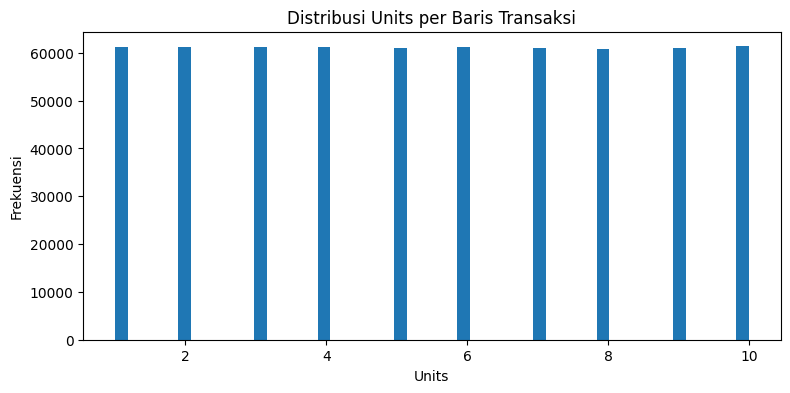

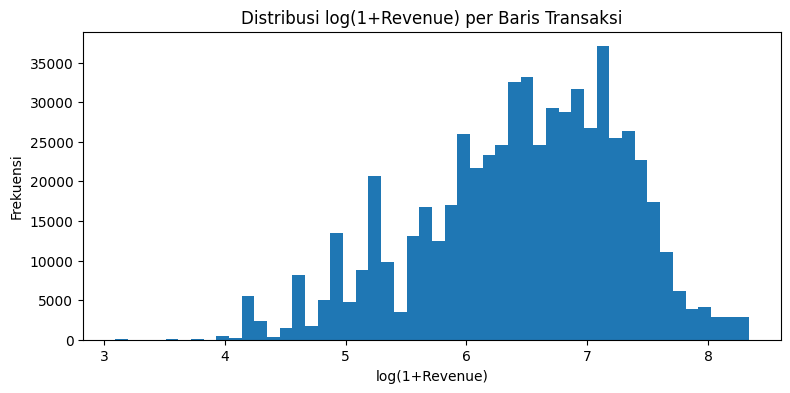

,0.01,0.05,0.25,0.50,0.75,0.95,0.99
Revenue,65.0,130.0,388.000000,700.000000,1221.000000,2040.000000,3288.00
ProfitMargin,0.0,0.0,0.230769,0.341085,0.618026,0.862069,0.88


Catatan interpretasi:
- Revenue yang sangat condong ke kanan (right-skewed) biasanya menandakan sebagian kecil transaksi bernilai besar.
- ProfitMargin ekstrem (sangat rendah/tinggi) perlu ditinjau: bisa karena harga/cost tidak konsisten atau produk tertentu.


In [10]:
# Distribusi Units
plt.figure(figsize=(9,4))
plt.hist(sales_clean["Units"], bins=50)
plt.title("Distribusi Units per Baris Transaksi")
plt.xlabel("Units")
plt.ylabel("Frekuensi")
plt.show()

# Distribusi Revenue (gunakan log-scale via transformasi agar lebih informatif)
rev = sales_clean["Revenue"].clip(lower=0)
rev_log = np.log1p(rev)

plt.figure(figsize=(9,4))
plt.hist(rev_log, bins=50)
plt.title("Distribusi log(1+Revenue) per Baris Transaksi")
plt.xlabel("log(1+Revenue)")
plt.ylabel("Frekuensi")
plt.show()

# Ringkasan kuantil untuk Revenue dan ProfitMargin
summary = sales_clean[["Revenue","ProfitMargin"]].quantile([0.01,0.05,0.25,0.5,0.75,0.95,0.99]).T
display(summary)

print("Catatan interpretasi:")
print("- Revenue yang sangat condong ke kanan (right-skewed) biasanya menandakan sebagian kecil transaksi bernilai besar.")
print("- ProfitMargin ekstrem (sangat rendah/tinggi) perlu ditinjau: bisa karena harga/cost tidak konsisten atau produk tertentu.")


## Insight 2 — Performa Regional

Tujuan:
- Membandingkan Revenue, Profit, dan Profit Margin per **Region**
- Menemukan region dengan *revenue besar tetapi margin rendah* (prioritas perbaikan)


/tmp/ipykernel_3792/3263666856.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Region", dropna=False)


,Region,Revenue,Profit,Units,Txn,ProfitMargin
1,East,247841829,110921134,1575698,286808,0.447548
0,Central,193977629,87026968,1234043,224359,0.448644
2,West,90462288,42245195,550329,99984,0.466992
3,Unknown,0,0,0,0,NaN


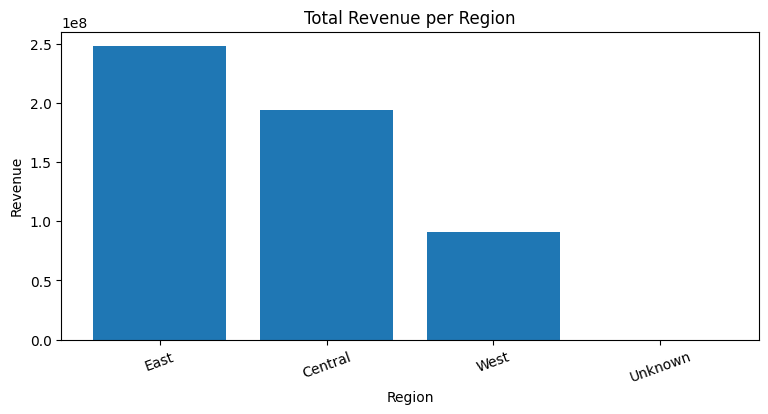

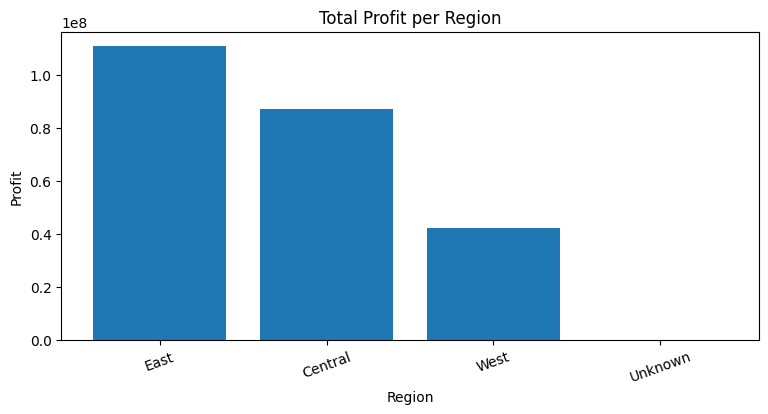

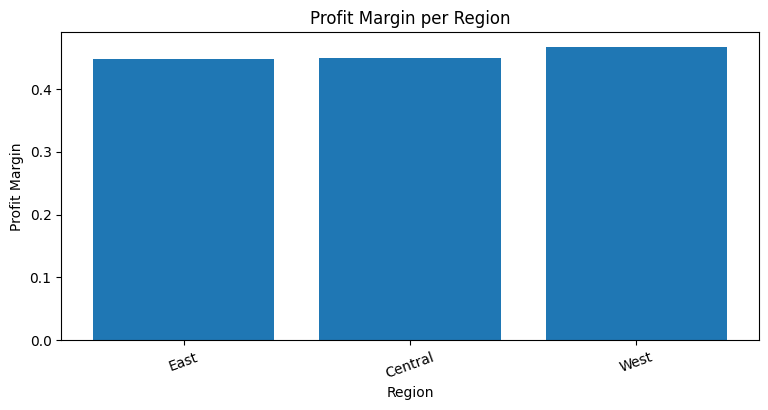

Insight ringkas:
- Region dengan Revenue terbesar: East
- Region dengan Profit Margin terendah: East
Fokus perbaikan biasanya ada pada kombinasi: revenue tinggi + margin rendah.


In [11]:
region_perf = (sales_clean
               .groupby("Region", dropna=False)
               .agg(Revenue=("Revenue","sum"),
                    Profit=("Profit","sum"),
                    Units=("Units","sum"),
                    Txn=("Revenue","size"))
               .reset_index())
region_perf["ProfitMargin"] = np.where(region_perf["Revenue"]!=0, region_perf["Profit"]/region_perf["Revenue"], np.nan)
region_perf = region_perf.sort_values("Revenue", ascending=False)

display(region_perf)

# Plot Revenue & Profit per region
plt.figure(figsize=(9,4))
plt.bar(region_perf["Region"].astype(str), region_perf["Revenue"])
plt.title("Total Revenue per Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(9,4))
plt.bar(region_perf["Region"].astype(str), region_perf["Profit"])
plt.title("Total Profit per Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=20)
plt.show()

# Profit Margin per region
plt.figure(figsize=(9,4))
plt.bar(region_perf["Region"].astype(str), region_perf["ProfitMargin"])
plt.title("Profit Margin per Region")
plt.xlabel("Region")
plt.ylabel("Profit Margin")
plt.xticks(rotation=20)
plt.show()

# Insight otomatis: region terbesar & margin terendah
top_rev_region = region_perf.iloc[0]["Region"]
worst_margin_region = region_perf.sort_values("ProfitMargin").iloc[0]["Region"]

print(f"Insight ringkas:")
print(f"- Region dengan Revenue terbesar: {top_rev_region}")
print(f"- Region dengan Profit Margin terendah: {worst_margin_region}")
print("Fokus perbaikan biasanya ada pada kombinasi: revenue tinggi + margin rendah.")


## Insight 3 — Tren Profit Margin dari Waktu ke Waktu

Tujuan:
- Melihat tren bulanan Revenue & Profit
- Memantau perubahan Profit Margin (indikasi perubahan mix produk, perubahan biaya, atau channel mix)


/tmp/ipykernel_3792/286651221.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("YearMonth", dropna=False)


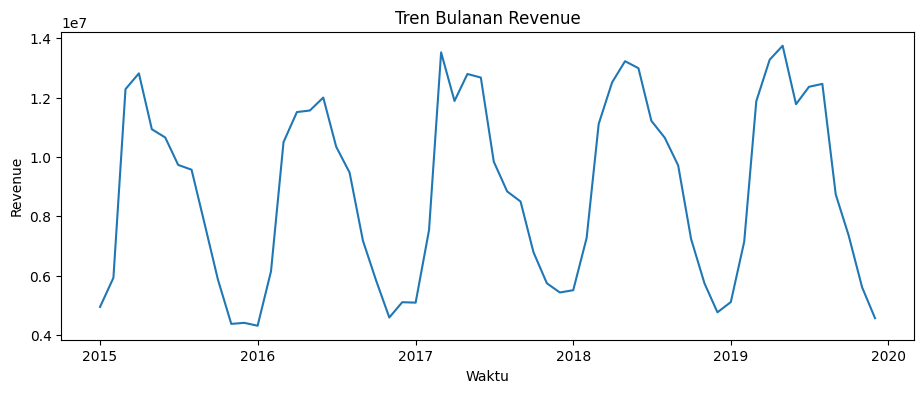

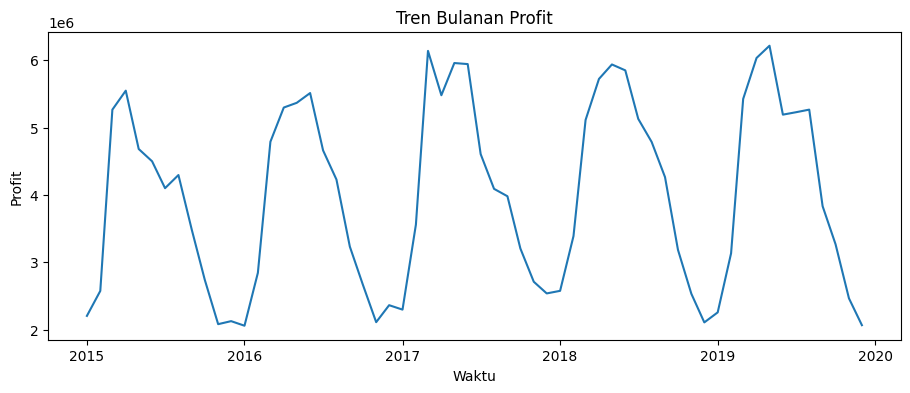

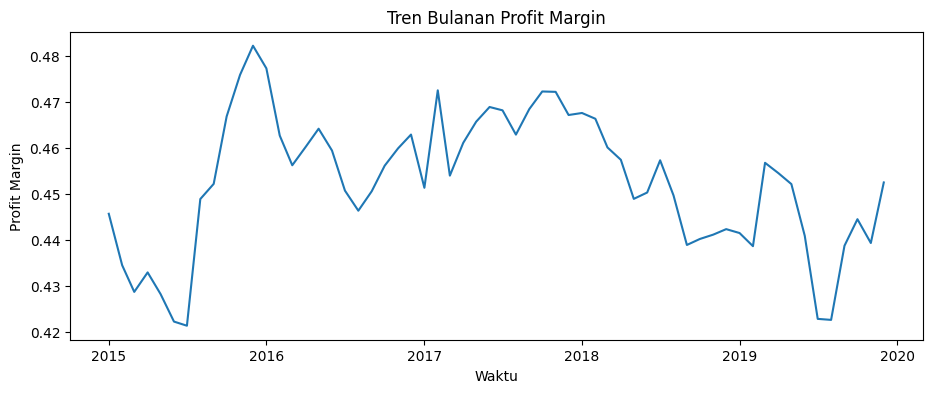

Insight ringkas:
- Profit Margin tertinggi: 48.22% pada 2015-12
- Profit Margin terendah : 42.14% pada 2015-07
Langkah lanjutan: bandingkan mix Region/Category/Channel pada bulan terburuk vs bulan normal.


In [13]:
monthly = (sales_clean
           .groupby("YearMonth", dropna=False)
           .agg(Revenue=("Revenue","sum"),
                Profit=("Profit","sum"),
                Units=("Units","sum"))
           .reset_index())

monthly["ProfitMargin"] = np.where(monthly["Revenue"]!=0, monthly["Profit"]/monthly["Revenue"], np.nan)

# Urutkan berdasarkan waktu (konversi ke string terlebih dahulu sebelum penggabungan)
monthly["YearMonth_dt"] = pd.to_datetime(monthly["YearMonth"].astype(str) + "-01")
monthly = monthly.sort_values("YearMonth_dt")

plt.figure(figsize=(11,4))
plt.plot(monthly["YearMonth_dt"], monthly["Revenue"])
plt.title("Tren Bulanan Revenue")
plt.xlabel("Waktu")
plt.ylabel("Revenue")
plt.show()

plt.figure(figsize=(11,4))
plt.plot(monthly["YearMonth_dt"], monthly["Profit"])
plt.title("Tren Bulanan Profit")
plt.xlabel("Waktu")
plt.ylabel("Profit")
plt.show()

plt.figure(figsize=(11,4))
plt.plot(monthly["YearMonth_dt"], monthly["ProfitMargin"])
plt.title("Tren Bulanan Profit Margin")
plt.xlabel("Waktu")
plt.ylabel("Profit Margin")
plt.show()

# Bulan terbaik/terburuk untuk margin
best = monthly.loc[monthly["ProfitMargin"].idxmax()]
worst = monthly.loc[monthly["ProfitMargin"].idxmin()]

print("Insight ringkas:")
print(f"- Profit Margin tertinggi: {best['ProfitMargin']:.2%} pada {best['YearMonth']}")
print(f"- Profit Margin terendah : {worst['ProfitMargin']:.2%} pada {worst['YearMonth']}")
print("Langkah lanjutan: bandingkan mix Region/Category/Channel pada bulan terburuk vs bulan normal.")

## Insight 4 — Analisis Channel & Device (Campaign)

Tujuan:
- Membandingkan performa berdasarkan **TrafficChannel** dan **Device**
- Menemukan channel/device yang menghasilkan revenue tinggi tetapi margin rendah (atau sebaliknya)


/tmp/ipykernel_3792/3190719720.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("TrafficChannel", dropna=False)


,TrafficChannel,Revenue,Profit,Txn,ProfitMargin
4,Organic Search,127922559,58606940,145481,0.458144
6,SEO,80393442,35914684,91469,0.446736
7,SMO,76773874,34633830,88132,0.451115
5,SEM,75985553,34343108,88118,0.451969
2,Email,62008601,27972946,71793,0.451114
0,Affliliate,47975939,21405129,55040,0.446164
1,Banner,33842128,15343089,38699,0.453372
3,Mail,27379650,11973571,32419,0.437316


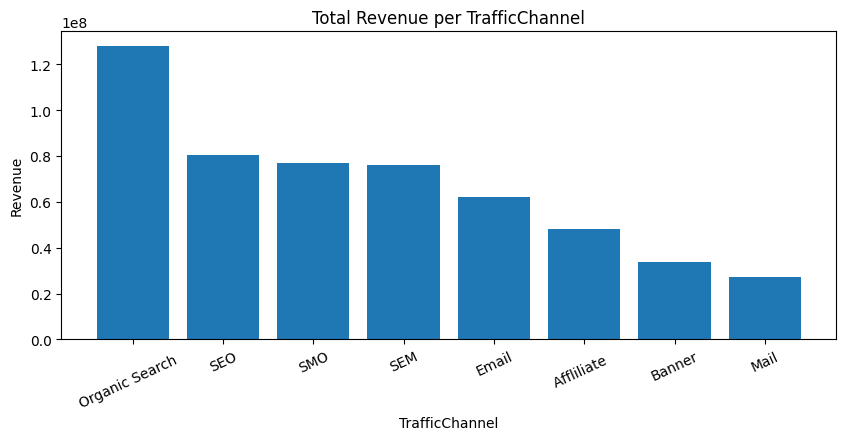

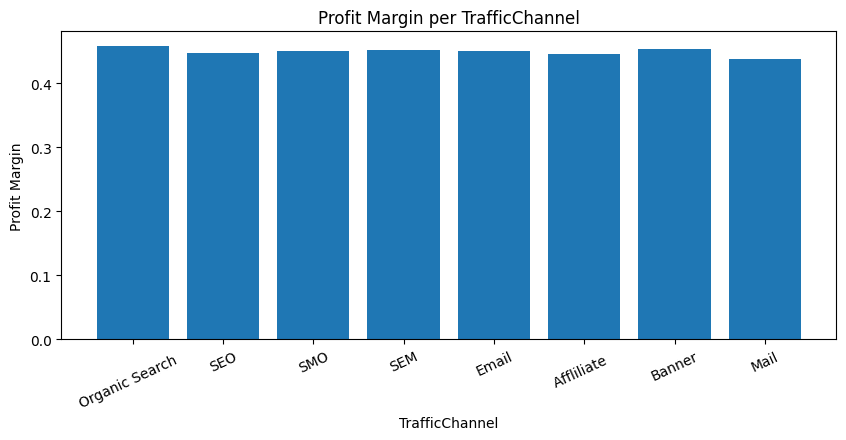

/tmp/ipykernel_3792/3190719720.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Device", dropna=False)


,Device,Revenue,Profit,Txn,ProfitMargin
0,Desktop,173287014,77961477,198745,0.449898
3,Tablet,163383906,74128965,187857,0.453710
2,Mobile,158741450,71896040,181324,0.452913
1,Laptop,27379650,11973571,32419,0.437316
4,Television,9489726,4233244,10806,0.446087


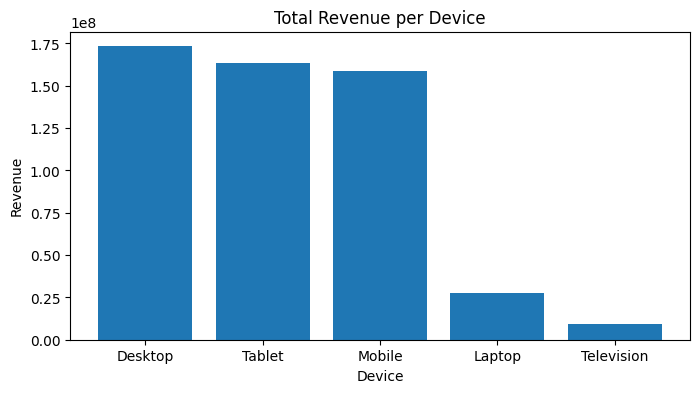

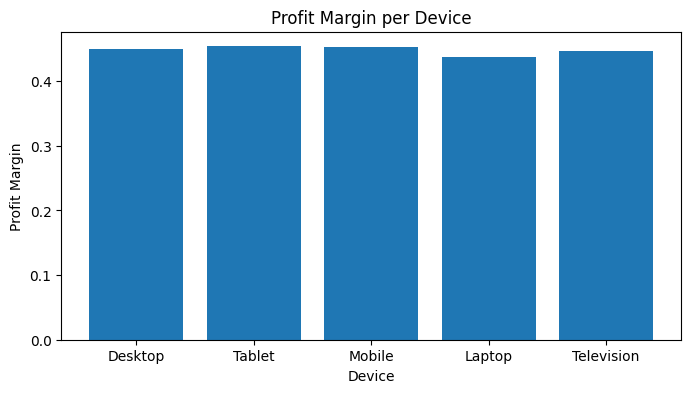

Catatan interpretasi:
- Jika ada channel dengan margin rendah namun volume tinggi, evaluasi strategi promosi, CAC, atau mix produk.
- Perbedaan device dapat mengindikasikan perbedaan perilaku pembelian atau perbedaan campaign.


In [14]:
# Performance per channel
chan = (sales_clean
        .groupby("TrafficChannel", dropna=False)
        .agg(Revenue=("Revenue","sum"),
             Profit=("Profit","sum"),
             Txn=("Revenue","size"))
        .reset_index())
chan["ProfitMargin"] = np.where(chan["Revenue"]!=0, chan["Profit"]/chan["Revenue"], np.nan)
chan = chan.sort_values("Revenue", ascending=False)

display(chan)

plt.figure(figsize=(10,4))
plt.bar(chan["TrafficChannel"].astype(str), chan["Revenue"])
plt.title("Total Revenue per TrafficChannel")
plt.xlabel("TrafficChannel")
plt.ylabel("Revenue")
plt.xticks(rotation=25)
plt.show()

plt.figure(figsize=(10,4))
plt.bar(chan["TrafficChannel"].astype(str), chan["ProfitMargin"])
plt.title("Profit Margin per TrafficChannel")
plt.xlabel("TrafficChannel")
plt.ylabel("Profit Margin")
plt.xticks(rotation=25)
plt.show()

# Performance per device
dev = (sales_clean
       .groupby("Device", dropna=False)
       .agg(Revenue=("Revenue","sum"),
            Profit=("Profit","sum"),
            Txn=("Revenue","size"))
       .reset_index())
dev["ProfitMargin"] = np.where(dev["Revenue"]!=0, dev["Profit"]/dev["Revenue"], np.nan)
dev = dev.sort_values("Revenue", ascending=False)

display(dev)

plt.figure(figsize=(8,4))
plt.bar(dev["Device"].astype(str), dev["Revenue"])
plt.title("Total Revenue per Device")
plt.xlabel("Device")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(8,4))
plt.bar(dev["Device"].astype(str), dev["ProfitMargin"])
plt.title("Profit Margin per Device")
plt.xlabel("Device")
plt.ylabel("Profit Margin")
plt.xticks(rotation=0)
plt.show()

print("Catatan interpretasi:")
print("- Jika ada channel dengan margin rendah namun volume tinggi, evaluasi strategi promosi, CAC, atau mix produk.")
print("- Perbedaan device dapat mengindikasikan perbedaan perilaku pembelian atau perbedaan campaign.")


## Insight 5 — Analisis Produk (Category, Segment, Top Product)

Tujuan:
- Menentukan kategori/segmen sebagai kontributor revenue & profit terbesar
- Mengidentifikasi kategori ber-margin rendah (kandidat efisiensi biaya atau penyesuaian harga)
- Menggunakan prinsip Pareto (top products) untuk fokus prioritas


/tmp/ipykernel_3792/3849852701.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Category", dropna=False)


,Category,Revenue,Profit,Units,Txn,ProfitMargin
3,Urban,463124720,208955506,2807701,510830,0.451186
1,Mix,33877407,16858297,269155,48991,0.497627
0,Accessory,22882986,6979540,199667,36191,0.305010
4,Youth,12371542,7390228,83390,15109,0.597357
2,Rural,25091,9726,157,30,0.387629


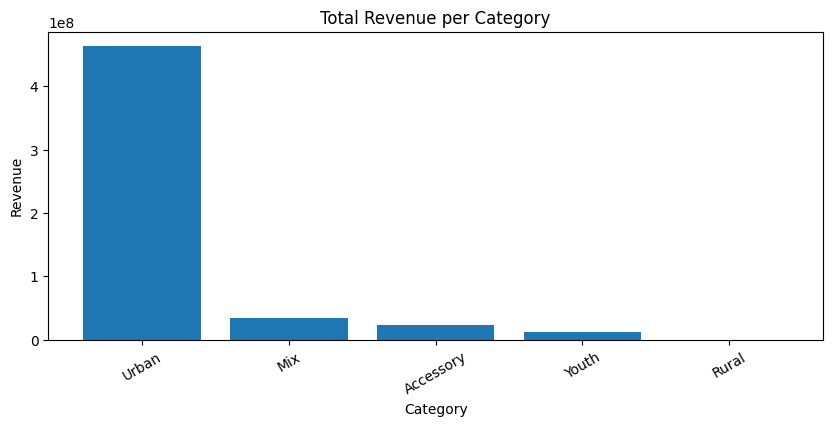

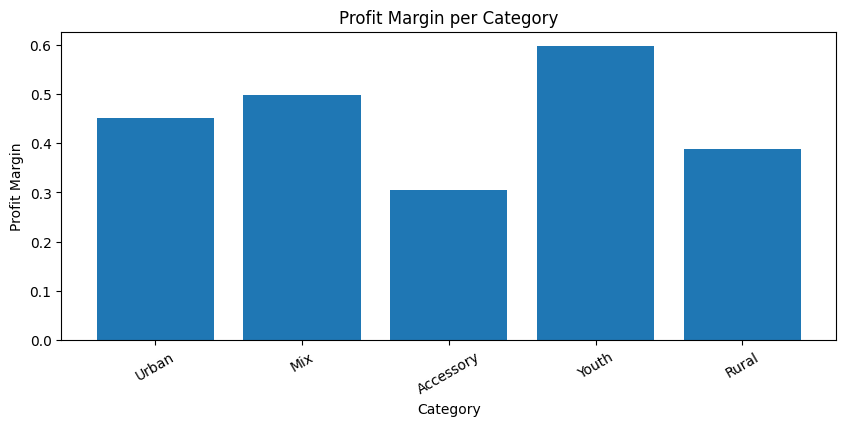

/tmp/ipykernel_3792/3849852701.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Product", dropna=False)


,Product,Revenue,Profit,Units,ProfitMargin
143,Maximus UM-54,34061065,9129770,351145,0.268041
38,Maximus UC-39,26523075,17551818,65009,0.661757
154,Maximus UM-70,21905933,9893002,100949,0.451613
136,Maximus UM-43,20045720,4127060,117916,0.205882
110,Maximus UM-11,19604892,4590330,300114,0.234142
152,Maximus UM-66,19058575,7948600,90325,0.417062
18,Maximus UC-16,18985736,12501664,46648,0.658477
49,Maximus UC-50,17772204,1685688,115600,0.094850
169,Maximus UM-96,16600518,10983171,83841,0.661616
157,Maximus UM-75,16100175,7820085,92001,0.485714


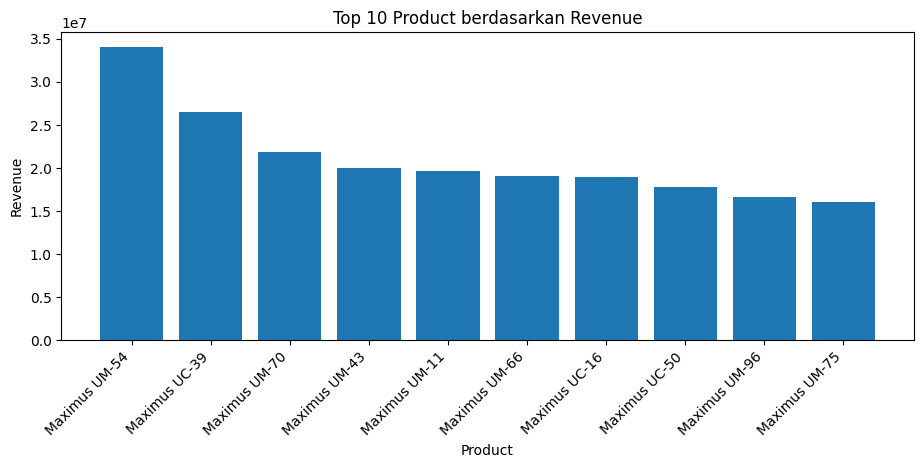

Insight ringkas:
- Kontribusi kumulatif revenue untuk top 20 product: 62.26%
Jika persentase tinggi, fokus pada perbaikan margin di produk-produk teratas akan berdampak besar.


/tmp/ipykernel_3792/3849852701.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prod_rev = (sales_clean.groupby("Product")["Revenue"].sum().sort_values(ascending=False))


In [15]:
# Agregasi per Category
cat = (sales_clean
       .groupby("Category", dropna=False)
       .agg(Revenue=("Revenue","sum"),
            Profit=("Profit","sum"),
            Units=("Units","sum"),
            Txn=("Revenue","size"))
       .reset_index())
cat["ProfitMargin"] = np.where(cat["Revenue"]!=0, cat["Profit"]/cat["Revenue"], np.nan)
cat = cat.sort_values("Revenue", ascending=False)
display(cat)

plt.figure(figsize=(10,4))
plt.bar(cat["Category"].astype(str), cat["Revenue"])
plt.title("Total Revenue per Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10,4))
plt.bar(cat["Category"].astype(str), cat["ProfitMargin"])
plt.title("Profit Margin per Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin")
plt.xticks(rotation=30)
plt.show()

# Top 10 product by Revenue
top_prod = (sales_clean
            .groupby("Product", dropna=False)
            .agg(Revenue=("Revenue","sum"),
                 Profit=("Profit","sum"),
                 Units=("Units","sum"))
            .reset_index()
            .sort_values("Revenue", ascending=False)
            .head(10))
top_prod["ProfitMargin"] = np.where(top_prod["Revenue"]!=0, top_prod["Profit"]/top_prod["Revenue"], np.nan)
display(top_prod)

plt.figure(figsize=(11,4))
plt.bar(top_prod["Product"].astype(str), top_prod["Revenue"])
plt.title("Top 10 Product berdasarkan Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.show()

# Pareto: kontribusi revenue top N product
prod_rev = (sales_clean.groupby("Product")["Revenue"].sum().sort_values(ascending=False))
pareto = prod_rev.cumsum() / prod_rev.sum()
share_20 = float(pareto.iloc[min(19, len(pareto)-1)]) if len(pareto)>0 else np.nan

print("Insight ringkas:")
print(f"- Kontribusi kumulatif revenue untuk top 20 product: {share_20:.2%}")
print("Jika persentase tinggi, fokus pada perbaikan margin di produk-produk teratas akan berdampak besar.")


## Insight 6 — Segmentasi Pelanggan (RFM-lite)

Tujuan:
- Mengelompokkan pelanggan berdasarkan nilai (revenue/profit) dan aktivitas (jumlah transaksi)
- Menentukan segmen prioritas: **High Value**, **Growth**, **At Risk/Low Value**

Catatan:
- Data ini berbasis baris transaksi (*line item*). Angka transaksi merepresentasikan jumlah baris, bukan nomor invoice.


,Segment,Customers,Revenue,Profit,AvgTxn,ProfitMargin
0,Growth,106650,216159253,101628996,2.044266,0.470158
1,High Value,65746,183708144,84657935,2.783333,0.460828
3,Regular,82032,108739059,45041598,1.973681,0.414217
2,Low Value,28168,23675290,8864768,1.712298,0.374431


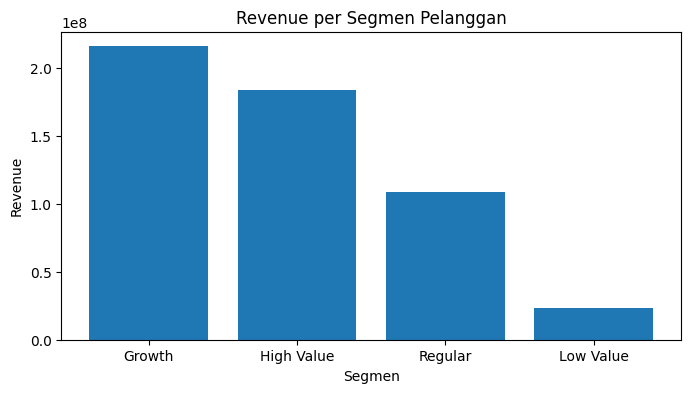

Insight ringkas:
- Segmen kontributor revenue terbesar: Growth
- Rekomendasi: prioritaskan retensi High Value, dan program upsell untuk Growth/Regular.


In [16]:
cust_agg = (sales_clean
            .groupby("CustomerID", dropna=False)
            .agg(Txn=("Revenue","size"),
                 Units=("Units","sum"),
                 Revenue=("Revenue","sum"),
                 Profit=("Profit","sum"),
                 LastDate=("Date","max"))
            .reset_index())
cust_agg["ProfitMargin"] = np.where(cust_agg["Revenue"]!=0, cust_agg["Profit"]/cust_agg["Revenue"], np.nan)

# Skor sederhana berbasis kuantil (RFM-lite):
# R: recency (lebih kecil lebih baik), F: Txn, M: Revenue
ref_date = sales_clean["Date"].max()
cust_agg["RecencyDays"] = (ref_date - cust_agg["LastDate"]).dt.days

cust_agg["R_Score"] = pd.qcut(cust_agg["RecencyDays"], 4, labels=[4,3,2,1])  # paling recent = 4
cust_agg["F_Score"] = pd.qcut(cust_agg["Txn"].rank(method="first"), 4, labels=[1,2,3,4])
cust_agg["M_Score"] = pd.qcut(cust_agg["Revenue"].rank(method="first"), 4, labels=[1,2,3,4])

cust_agg["RFM_Score"] = cust_agg["R_Score"].astype(int) + cust_agg["F_Score"].astype(int) + cust_agg["M_Score"].astype(int)

def label_segment(score: int) -> str:
    if score >= 10:
        return "High Value"
    elif score >= 7:
        return "Growth"
    elif score >= 5:
        return "Regular"
    else:
        return "Low Value"

cust_agg["Segment"] = cust_agg["RFM_Score"].apply(label_segment)

seg = (cust_agg
       .groupby("Segment")
       .agg(Customers=("CustomerID","nunique"),
            Revenue=("Revenue","sum"),
            Profit=("Profit","sum"),
            AvgTxn=("Txn","mean"))
       .reset_index())
seg["ProfitMargin"] = np.where(seg["Revenue"]!=0, seg["Profit"]/seg["Revenue"], np.nan)
seg = seg.sort_values("Revenue", ascending=False)
display(seg)

plt.figure(figsize=(8,4))
plt.bar(seg["Segment"].astype(str), seg["Revenue"])
plt.title("Revenue per Segmen Pelanggan")
plt.xlabel("Segmen")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

print("Insight ringkas:")
top_seg = seg.iloc[0]["Segment"]
print(f"- Segmen kontributor revenue terbesar: {top_seg}")
print("- Rekomendasi: prioritaskan retensi High Value, dan program upsell untuk Growth/Regular.")


## Insight 7 — Outlier Detection & Kandidat Root Cause

Tujuan:
- Mengidentifikasi transaksi dengan nilai ekstrem (Revenue/Units/ProfitMargin)
- Menilai apakah outlier tersebut valid (peluang) atau indikasi masalah (data/operasional)
- Menghubungkan outlier dengan Region, Category, Channel untuk hipotesis root cause


In [17]:
# Outlier berdasarkan Revenue (IQR)
q1, q3 = sales_clean["Revenue"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr

out_rev = sales_clean[sales_clean["Revenue"] > upper].copy()
print(f"Outlier Revenue (Revenue > {upper:,.2f}): {len(out_rev):,} baris ({len(out_rev)/len(sales_clean):.2%})")

display(out_rev.sort_values("Revenue", ascending=False).head(10)[
    ["Date","Region","Category","Segment","TrafficChannel","Device","Units","Unit Price","Revenue","Unit Cost","Cost","Profit","ProfitMargin"]
])

# Outlier ProfitMargin rendah
pm_q01 = sales_clean["ProfitMargin"].quantile(0.01)
low_pm = sales_clean[sales_clean["ProfitMargin"] <= pm_q01].copy()
print(f"1% ProfitMargin terendah (<= {pm_q01:.2%}): {len(low_pm):,} baris")

display(low_pm.sort_values("ProfitMargin").head(10)[
    ["Date","Region","Category","Segment","TrafficChannel","Device","Units","Revenue","Profit","ProfitMargin","Unit Cost","Unit Price"]
])

print("Hipotesis investigasi:")
print("- Jika ProfitMargin rendah terkonsentrasi pada region/kategori tertentu, evaluasi struktur biaya atau strategi harga.")
print("- Jika outlier revenue terkonsentrasi pada channel tertentu, cek efektivitas campaign dan kapasitas fulfillment.")


Outlier Revenue (Revenue > 2,470.50): 16,665 baris (2.73%)


,Date,Region,Category,Segment,TrafficChannel,Device,Units,Unit Price,Revenue,Unit Cost,Cost,Profit,ProfitMargin
517678,2015-09-27,East,Urban,Moderation,SEO,Desktop,10,418,4180,142,1420,2760,0.660287
531717,2015-08-15,East,Urban,Moderation,SEO,Desktop,10,418,4180,142,1420,2760,0.660287
496678,2016-01-21,East,Urban,Moderation,Organic Search,Mobile,10,418,4180,142,1420,2760,0.660287
460454,2016-05-04,West,Urban,Moderation,SMO,Mobile,10,418,4180,142,1420,2760,0.660287
434994,2016-06-29,West,Urban,Moderation,SMO,Desktop,10,418,4180,142,1420,2760,0.660287
483982,2016-03-12,East,Urban,Moderation,Organic Search,Tablet,10,418,4180,142,1420,2760,0.660287
491686,2016-02-16,East,Urban,Moderation,Organic Search,Tablet,10,418,4180,142,1420,2760,0.660287
509072,2015-10-30,Central,Urban,Moderation,Email,Desktop,10,418,4180,142,1420,2760,0.660287
531944,2015-08-14,East,Urban,Moderation,Organic Search,Desktop,10,418,4180,142,1420,2760,0.660287
466532,2016-04-22,East,Urban,Moderation,Mail,Laptop,10,418,4180,142,1420,2760,0.660287


1% ProfitMargin terendah (<= 0.00%): 30,705 baris


,Date,Region,Category,Segment,TrafficChannel,Device,Units,Revenue,Profit,ProfitMargin,Unit Cost,Unit Price
611162,2015-01-02,East,Urban,Moderation,SEO,Desktop,10,1390,0,0.0,139,139
611161,2015-01-02,East,Urban,Moderation,SEO,Desktop,8,1112,0,0.0,139,139
611160,2015-01-02,Central,Urban,Moderation,SEO,Desktop,2,278,0,0.0,139,139
611159,2015-01-02,East,Urban,Moderation,SEO,Desktop,2,278,0,0.0,139,139
611158,2015-01-02,Central,Urban,Moderation,SEO,Desktop,5,695,0,0.0,139,139
611156,2015-01-02,East,Urban,Moderation,SEO,Desktop,3,417,0,0.0,139,139
611155,2015-01-02,West,Urban,Moderation,SEO,Desktop,1,139,0,0.0,139,139
611154,2015-01-02,East,Urban,Convenience,SEM,Desktop,1,139,0,0.0,139,139
611083,2015-01-03,West,Urban,Moderation,SEO,Desktop,3,417,0,0.0,139,139
611079,2015-01-03,East,Urban,Convenience,SEM,Desktop,6,834,0,0.0,139,139


Hipotesis investigasi:
- Jika ProfitMargin rendah terkonsentrasi pada region/kategori tertentu, evaluasi struktur biaya atau strategi harga.
- Jika outlier revenue terkonsentrasi pada channel tertentu, cek efektivitas campaign dan kapasitas fulfillment.


## 5) Analisis Korelasi (Numerik)

Tujuan:
- Melihat hubungan antar variabel numerik (Units, Unit Price/Cost, Revenue, Profit, ProfitMargin)
- Korelasi bukan kausalitas, namun membantu mengidentifikasi arah hubungan untuk investigasi lanjutan


,Units,Unit Price,Unit Cost,Revenue,Cost,Profit,ProfitMargin
Units,1.000000,0.001827,0.000218,0.684968,0.727321,0.445298,0.000983
Unit Price,0.001827,1.000000,0.520981,0.647459,0.318878,0.694876,0.485381
Unit Cost,0.000218,0.520981,1.000000,0.336720,0.608358,0.032489,-0.439407
Revenue,0.684968,0.647459,0.336720,1.000000,0.759041,0.875141,0.314178
Cost,0.727321,0.318878,0.608358,0.759041,1.000000,0.349248,-0.265900
Profit,0.445298,0.694876,0.032489,0.875141,0.349248,1.000000,0.649812
ProfitMargin,0.000983,0.485381,-0.439407,0.314178,-0.265900,0.649812,1.000000


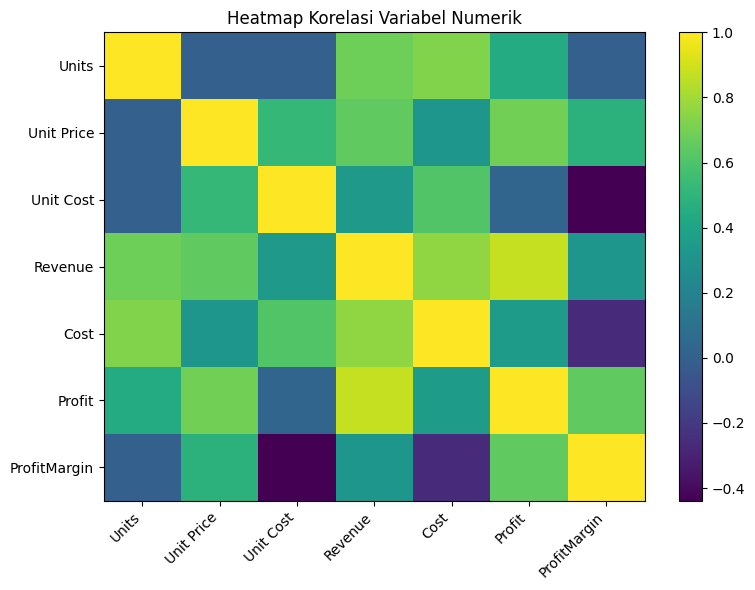

Catatan interpretasi:
- Profit biasanya sangat berkorelasi dengan Revenue karena Profit = Revenue - Cost.
- ProfitMargin dapat menurun bila Cost meningkat lebih cepat daripada Revenue (misal biaya tinggi pada kategori tertentu).


In [18]:
num_cols = ["Units", "Unit Price", "Unit Cost", "Revenue", "Cost", "Profit", "ProfitMargin"]
num_cols = [c for c in num_cols if c in sales_clean.columns]

corr = sales_clean[num_cols].corr(numeric_only=True)
display(corr)

# Heatmap sederhana dengan matplotlib (tanpa seaborn)
plt.figure(figsize=(8,6))
plt.imshow(corr.values, aspect="auto")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Heatmap Korelasi Variabel Numerik")
plt.tight_layout()
plt.show()

print("Catatan interpretasi:")
print("- Profit biasanya sangat berkorelasi dengan Revenue karena Profit = Revenue - Cost.")
print("- ProfitMargin dapat menurun bila Cost meningkat lebih cepat daripada Revenue (misal biaya tinggi pada kategori tertentu).")


## 6) Critical Insight & Rekomendasi Tindakan

Pada bagian ini kita menyimpulkan “leverage” terbesar untuk perbaikan profit margin:
1. Area dengan **Revenue besar** namun **Profit Margin rendah**
2. Kombinasi **Region × Category** yang paling bermasalah
3. Channel/Device yang perlu dioptimalkan

Output di bawah bersifat data-driven dan dapat dijadikan bahan *action plan*.


In [19]:
# Matriks Region x Category
pivot = (sales_clean
         .groupby(["Region","Category"], dropna=False)
         .agg(Revenue=("Revenue","sum"),
              Profit=("Profit","sum"),
              Txn=("Revenue","size"))
         .reset_index())
pivot["ProfitMargin"] = np.where(pivot["Revenue"]!=0, pivot["Profit"]/pivot["Revenue"], np.nan)

# Fokus: sel dengan revenue signifikan (di atas persentil 75) namun margin rendah (di bawah persentil 25)
rev_thr = pivot["Revenue"].quantile(0.75)
pm_thr  = pivot["ProfitMargin"].quantile(0.25)

candidates = pivot[(pivot["Revenue"] >= rev_thr) & (pivot["ProfitMargin"] <= pm_thr)].copy()
candidates = candidates.sort_values(["Revenue","ProfitMargin"], ascending=[False, True])

print("Kandidat prioritas perbaikan (Revenue tinggi + Margin rendah):")
display(candidates.head(15))

if len(candidates) > 0:
    top_issue = candidates.iloc[0]
    print("Critical Insight (berdasarkan aturan kandidat):")
    print(f"- Kombinasi prioritas: Region={top_issue['Region']} | Category={top_issue['Category']}")
    print(f"- Revenue: {top_issue['Revenue']:,.0f} | Profit: {top_issue['Profit']:,.0f} | Margin: {top_issue['ProfitMargin']:.2%}")
else:
    print("Tidak ada kandidat yang memenuhi aturan threshold (coba sesuaikan aturan atau gunakan analisis ranking).")

print("\nRekomendasi tindakan (umum):")
print("1) Audit biaya (Unit Cost) pada kombinasi Region/Category bermargin rendah: cek supplier, logistik, dan biaya operasional.")
print("2) Optimasi mix produk: dorong penjualan pada kategori/produk ber-margin tinggi melalui campaign dan rekomendasi.")
print("3) Evaluasi channel dengan margin rendah: cek efektivitas campaign, biaya akuisisi, dan penawaran yang mendorong produk bermargin rendah.")
print("4) Program retensi pelanggan High Value: menjaga kontribusi profit tanpa perlu diskon agresif.")
print("5) Monitoring: buat dashboard bulanan (Revenue, Profit, Margin) per Region/Category/Channel untuk deteksi dini.")


Kandidat prioritas perbaikan (Revenue tinggi + Margin rendah):


/tmp/ipykernel_3792/1739557303.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Region","Category"], dropna=False)


,Region,Category,Revenue,Profit,Txn,ProfitMargin


Tidak ada kandidat yang memenuhi aturan threshold (coba sesuaikan aturan atau gunakan analisis ranking).

Rekomendasi tindakan (umum):
1) Audit biaya (Unit Cost) pada kombinasi Region/Category bermargin rendah: cek supplier, logistik, dan biaya operasional.
2) Optimasi mix produk: dorong penjualan pada kategori/produk ber-margin tinggi melalui campaign dan rekomendasi.
3) Evaluasi channel dengan margin rendah: cek efektivitas campaign, biaya akuisisi, dan penawaran yang mendorong produk bermargin rendah.
4) Program retensi pelanggan High Value: menjaga kontribusi profit tanpa perlu diskon agresif.
5) Monitoring: buat dashboard bulanan (Revenue, Profit, Margin) per Region/Category/Channel untuk deteksi dini.


## 7) Keterbatasan & Langkah Lanjutan

Keterbatasan pada dataset:
- Tidak tersedia variabel **diskon** atau **return**; jika bisnis memiliki diskon/return, analisis dapat diperluas untuk mengukur dampaknya terhadap margin.
- Transaksi direpresentasikan sebagai baris *line item* (Product × Customer × Date × Campaign). Jika ada konsep invoice/order, perlu tabel tambahan.

Langkah lanjutan yang direkomendasikan:
- Menambahkan data diskon/promo, return/refund, dan biaya pemasaran (CAC) bila tersedia
- Membangun model prediksi margin atau rekomendasi product-mix untuk meningkatkan profit margin
- Menerapkan kontrol eksperimen (A/B) pada campaign untuk menguji perubahan strategi
